# Salinity percentiles 

Using IAP salinity data for a 1deg grid form 1990 to 2023 determine percentile trends and make a nice plot

In [8]:
# download packcages

# load packages 
import numpy as np
import xarray as xr
# import datatree
import matplotlib
import math

# 
# from datatree import DataTree
# from xmip.postprocessing import _parse_metric

import cartopy.crs as ccrs

# import xskillscore as xs
import matplotlib.pyplot as plt
%matplotlib inline
import calendar
from matplotlib.lines import Line2D

import os
import re
import seaborn as sns
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from scipy.stats import norm

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from mpl_toolkits.basemap import Basemap
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.gridspec import GridSpec

import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np
import matplotlib.patches as patches

from scipy.stats import scoreatpercentile
from xarray import DataTree




## create a single dataset

In [9]:
# Initialize an empty list to store the filenames
filenames = []

# Loop through the years 1990 to 1999
for year in range(1990, 2000):
    # file path directory 
    dirct = f"/Users/isabelaconde/Desktop/salinity_data/Salinity_IAPdata_1990_1999/"
    # Loop through the months 1 to 12
    for month in range(1, 13):
        # Format the month to be zero-padded (e.g., 01, 02)
        month_str = f"{month:02}"
        # Generate the filename
        filename =dirct+ f"IAPv2_Salinity_monthly_1_6000m_year_{year}_month_{month_str}.nc"
        # Append to the list
        filenames.append(filename)
filenames
for year in range(2000, 2010):
    # file path directory 
    dirct = f"/Users/isabelaconde/Desktop/salinity_data/Salinity_IAPdata_2000_2009/"
    # Loop through the months 1 to 12
    for month in range(1, 13):
        # Format the month to be zero-padded (e.g., 01, 02)
        month_str = f"{month:02}"
        # Generate the filename
        filename = dirct+f"IAPv2_Salinity_monthly_1_6000m_year_{year}_month_{month_str}.nc"
        # Append to the list
        filenames.append(filename)


for year in range(2010, 2020):
    # file path directory 
    dirct = f"/Users/isabelaconde/Desktop/salinity_data/Salinity_IAPdata_2010_2019/"
    # Loop through the months 1 to 12
    for month in range(1, 13):
        # Format the month to be zero-padded (e.g., 01, 02)
        month_str = f"{month:02}"
        # Generate the filename
        filename = dirct+f"IAPv2_Salinity_monthly_1_6000m_year_{year}_month_{month_str}.nc"
        # Append to the list
        filenames.append(filename)

for year in range(2020, 2024):
    # file path directory 
    dirct = f"/Users/isabelaconde/Desktop/salinity_data/Salinity_IAPdata_2020_2023/"
    # Loop through the months 1 to 12
    for month in range(1, 13):
        # Format the month to be zero-padded (e.g., 01, 02)
        month_str = f"{month:02}"
        # Generate the filename
        filename = dirct+f"IAPv2_Salinity_monthly_1_6000m_year_{year}_month_{month_str}.nc"
        # Append to the list
        filenames.append(filename)





In [23]:
IAP_salinity = xr.open_mfdataset(filenames)

In [27]:
sss

<xarray.DataArray 'salinity' (time: 407, lat: 180, lon: 360)> Size: 105MB
dask.array<getitem, shape=(407, 180, 360), dtype=float32, chunksize=(1, 180, 360), chunktype=numpy.ndarray>
Coordinates:
  * lat        (lat) float32 720B -89.5 -88.5 -87.5 -86.5 ... 87.5 88.5 89.5
  * lon        (lon) float32 1kB 1.0 2.0 3.0 4.0 5.0 ... 357.0 358.0 359.0 360.0
  * time       (time) float32 2kB 0.0 1.99e+05 1.99e+05 ... 2.023e+05 2.023e+05
    depth_std  float32 4B 1.0
Attributes:
    long_name:      Salinity
    units:          Absolute Salinity (g/kg)
    standard_name:  Salinity

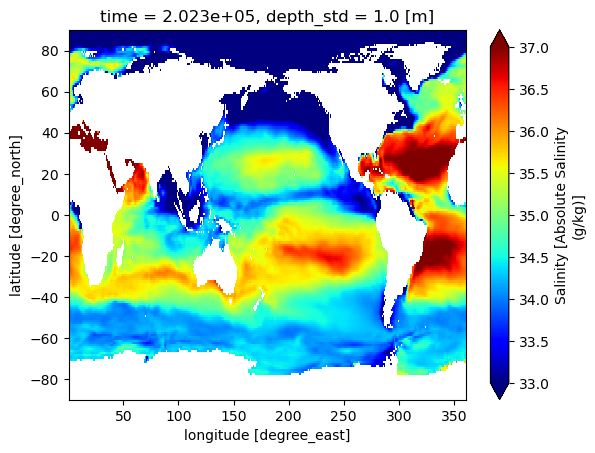

In [41]:

sss =IAP_salinity.sel(depth_std=1).salinity.isel(time = slice(1,-1))

sss.isel(time=-1).plot(cmap='jet', vmin=33, vmax=37)
# plt.pcolormesh(sss.lon, sss.lat, sss.isel(time=2), shading='auto', cmap='viridis')  # Plot for the first time step


## Determine trend - map 

In [42]:
def find_trend_values(dt,lat,lon):

    # Step 2: Reshape the data for polynomial fitting
    time, lat, lon = dt['time'].values, dt[lat].values, dt[lon].values
    sst_reshaped = dt.values.reshape(len(time), -1)
    
    # Step 4: Create empty arrays to store gradient and RMSE values
    gradient_values = np.empty_like(sst_reshaped[0])
    rmse_values = np.empty_like(sst_reshaped[0])
    
    # Step 5: Perform polynomial fitting at each grid point
    for i in range(len(sst_reshaped[0])):
        y = sst_reshaped[:, i]
        coefficients = np.polyfit(np.arange(len(time)), y, 1)
        # Step 6: Calculate gradient
        gradient_values[i] = coefficients[-2]  # Coefficient for x term (slope)
    

    # Step 7: Reshape the arrays back to the lat-lon grid
    gradient_values = gradient_values.reshape(lat.shape[0], lon.shape[0])
    # rmse_values = rmse_values.reshape(lat.shape[0], lon.shape[0])
    
    # Step 8: Create xarray DataArrays for gradient and RMSE
    gradient_da = xr.DataArray(gradient_values, coords={'lat': lat, 'lon': lon}, dims=['lat', 'lon'])
    
    return gradient_da 


sss_trend = find_trend_values(sss, 'lat', 'lon')

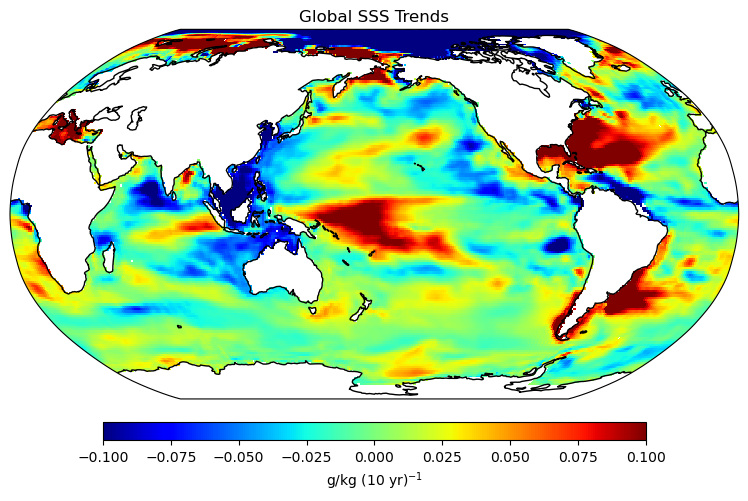

In [103]:
# Import necessary libraries
import matplotlib.pyplot as plt
import cartopy.crs as ccrs


# Set up the map with the Robinson projection
fig, ax = plt.subplots(
    figsize=(10, 6),
    subplot_kw={'projection': ccrs.Robinson(central_longitude=180)}  # Centered on tropical Pacific
)
ax.coastlines()

# Plot the data (your SST plot)
plot = (sss_trend * 10 * 12).plot(
    ax=ax,
    transform=ccrs.PlateCarree(),  # Data is in PlateCarree projection
    cmap='jet',
    add_colorbar=False,
    vmin=-0.1, vmax=0.1
)


# Add a custom color bar
cbar = fig.colorbar(
    plot,
    ax=ax,
    orientation='horizontal',
    pad=0.05,
    aspect=30,
    shrink=0.7
)
cbar.set_label(r'g/kg (10 yr)$^{-1}$')

plt.title("Global SSS Trends", fontsize=12)
plt.show()


# Find percentiles 
- global and tropical pacific

In [52]:
from xhistogram.xarray import histogram

def quantiles_xhist(data,temps):
    hist_T = data#.tos
    weights = np.cos(np.deg2rad(hist_T.lat))
    times = hist_T['time']
    const_area=np.r_[0:1:0.005]
    # temps = np.r_[12:34:0.5] # define temperatures for binning 
    
    temps_interp = np.empty([len(times),len(const_area)])
    
    for i in np.r_[0:len(times):1]:  
        h=histogram(hist_T[i],bins=temps,weights=weights).cumsum()
        hh = (h - h[0])/(h[-1]-h[0])
        temps_interp[i]=np.interp(const_area,hh,temps[1:])
    
    
    sst_area= xr.DataArray(temps_interp,coords={'time':times,'area':const_area})

    return(sst_area)

sss_percentiles = quantiles_xhist(sss, np.r_[30:40:0.5])
sss_percentiles


<xarray.DataArray (time: 405, area: 200)> Size: 648kB
array([[30.5       , 31.07503611, 31.67174574, ..., 37.37627833,
        37.5278303 , 38.1410186 ],
       [30.5       , 31.31329598, 31.77938449, ..., 37.39976539,
        37.57956943, 38.14273523],
       [30.5       , 31.53006234, 31.92865189, ..., 37.44285395,
        37.72188393, 38.31232448],
       ...,
       [30.5       , 31.0874598 , 31.52953162, ..., 37.4498351 ,
        37.6989369 , 38.18398245],
       [30.5       , 31.11946143, 31.5846011 , ..., 37.45240396,
        37.72183955, 38.22876133],
       [30.5       , 31.23745287, 31.67919935, ..., 37.46682049,
        37.74675598, 38.22977315]])
Coordinates:
  * time     (time) float32 2kB 1.99e+05 1.99e+05 ... 2.023e+05 2.023e+05
  * area     (area) float64 2kB 0.0 0.005 0.01 0.015 ... 0.98 0.985 0.99 0.995

In [55]:
# Find trend 

def find_trend_percentile(data):
    data = data
    x_val = np.arange(0, 405)
    # slope_array=np.empty(200))
    slope_array=[np.polyfit(x_val, data.isel(area=j), 1)[0] for j in range(200)]
    da = xr.DataArray(slope_array, coords ={'area':data.area.values},name = 'trend')
    return da

sss_percentile_trend = find_trend_percentile(sss_percentiles)



In [91]:
# mask out tropical pacific

def mask_pacific(data,lat,lon):
    temp_con = data.isel(time=0) # temperature grid to choose
    ##################
    import math
    import matplotlib
    import numpy as np
    
    LonsPts_pos = [130,120,110,110,110,260,270,270,277,291,291,130] #-np.ones(12)*360
    LatsPts_pos =[-20,-10,-5,10,20,20,15,15,10,5,-20,-20]
    x_pixel_pos = LonsPts_pos
    y_pixel_pos = LatsPts_pos
    
    temp_list = []
    for a, b in zip(x_pixel_pos, y_pixel_pos):
        temp_list.append([a, b])
    
    polygon = np.array(temp_list)
    
    xv, yv = temp_con[lon].values, temp_con[lat].values
    lon2d, lat2d = np.meshgrid(xv, yv)
    points = np.hstack((lon2d.reshape((-1,1)), lat2d.reshape((-1,1))))
    path = matplotlib.path.Path(polygon)
    mask = path.contains_points(points)
    mask.shape = lon2d.shape
    mask_bit_pos = mask*np.ones_like(lon2d)
    
    
    mask_tot = mask_bit_pos#+mask_bit_neg
    mask_zero = mask_bit_pos
    
    mask_tot[mask_tot==0] = np.nan
    mask_mods = mask_tot
    return mask_tot
######################

mask = mask_pacific(sss, 'lat', 'lon')
sss_trop_pacifc = (sss*mask_pacific(sss, 'lat', 'lon')).sel(lat = slice(-20,20)).sel(lon = slice(110, 290))

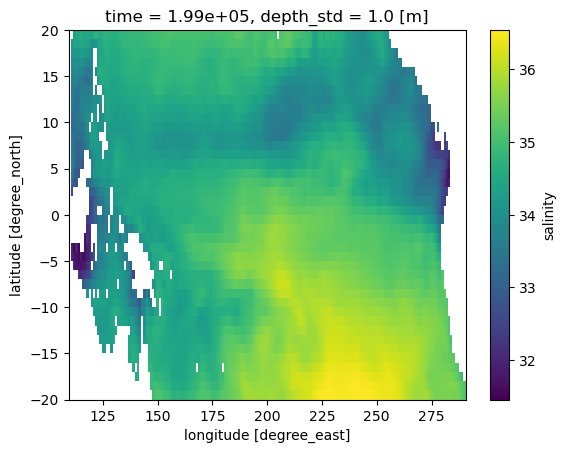

In [92]:
sss_trop_pacifc.isel(time=0).plot()

In [93]:
sss_trop_pacific_percentiles = quantiles_xhist(sss_trop_pacifc, np.r_[30:40:0.5])
sss_trop_pacific_percentile_trend = find_trend_percentile(sss_trop_pacific_percentiles)


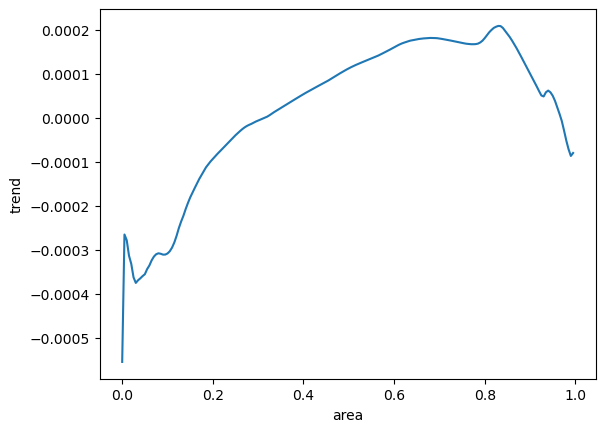

In [94]:
sss_trop_pacific_percentile_trend.plot()

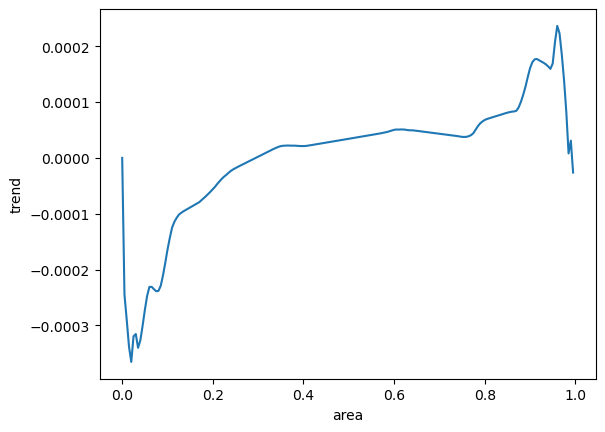

In [96]:
# tropics

sss_trop_percentiles = quantiles_xhist(sss.sel(lat=slice(-30,30)), np.r_[30:40:0.5])
sss_trop_percentile_trend = find_trend_percentile(sss_trop_percentiles)
sss_trop_percentile_trend.plot()


# plot nice

Text(0.5, 1.0, 'Trend at Each Sea Surface Salinity Precentile')

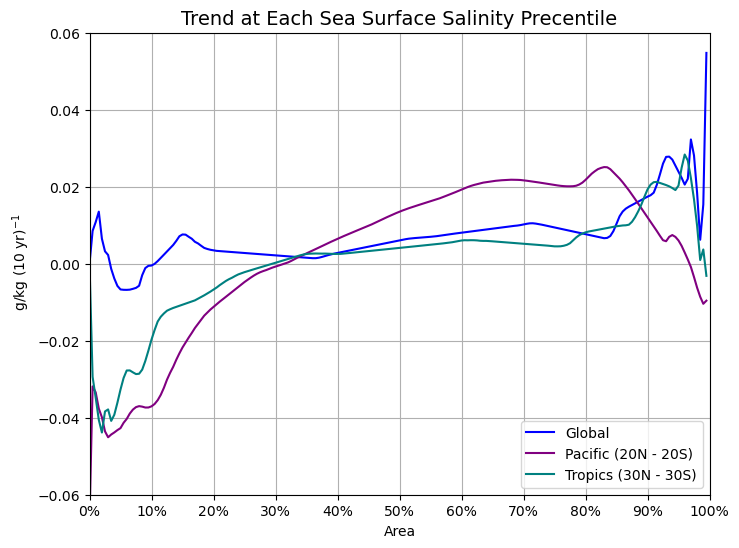

In [102]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6))


# plot percentile trends 
(sss_percentile_trend*10*12).plot(label='Global', color='blue')
(sss_trop_pacific_percentile_trend*10*12).plot(label='Pacific (20N - 20S)', color='purple')
(sss_trop_percentile_trend*10*12).plot(label='Tropics (30N - 30S)', color='teal')

# Modify x-axis labels to represent percentages
axes.set_xticks(np.linspace(0, 1, 11))  # 11 ticks for 0%, 10%, 20%, ..., 100%
axes.set_xticklabels(['{}%'.format(int(x * 100)) for x in np.linspace(0, 1, 11)])

# Add grid
axes.grid(True)


# Add legend
axes.legend(loc = 'lower right')
axes.set_xlim(0, 1)
axes.set_ylim(-0.06,0.06)
axes.set_ylabel(r' g/kg (10 yr)$^{-1}$')
axes.set_xlabel('Area')
plt.title('Trend at Each Sea Surface Salinity Precentile',fontsize=14)